In [1]:
!pip install -q fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.8 MB/s eta 0:00:0000:010:01


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

#####################################################
# Импортируем .py файлы с уже написанными функциями #
#####################################################

import sys
sys.path.append('/kaggle/input/datasets/faibus/diploma')

# функции для расчёта метрик
from metrics import (
    DEFAULT_METRICS,
    get_model_columns,
    compute_metrics_per_window,
    summarize_metrics,
    summarize_metrics_by_segments,
)

from best_model import plot_metrics_bars, intersect_cv_frames, summarize_money_metrics

In [3]:
real_demand = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/real_demand_data.parquet', engine='fastparquet')
real_demand = real_demand.rename(columns = {'date':'ds', 'real_demand':'y', 'SKU_id':'unique_id'})[['unique_id', 'ds', 'y']]

# Готовим данные по ценам
data  = pd.read_parquet('/kaggle/input/datasets/faibus/diploma/gmv_dataset.parquet', engine='fastparquet')
price_table = data \
    .query("Items_Acc != 0") \
    .groupby(['SKU_id']) \
    .agg({'GMV_wo_VAT_Acc':'sum', 'Items_Acc':'sum'}).reset_index()

price_table['price'] = price_table['GMV_wo_VAT_Acc'] / price_table['Items_Acc']
price_table = price_table[['SKU_id', 'price']]
price_table = price_table.rename(columns = {'SKU_id':'unique_id'})

# Прогнозы моделей

# smooth
arima_exog_smooth = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/arima_smooth.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
ml_smooth = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/ml_forecast_smooth_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
nl_smooth = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/neural_forecast_smooth_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
stat_smooth = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/smooth_forecast.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)

# erratic
arima_exog_erratic = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/arima_erratic.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
ml_erratic = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/ml_forecast_erratic_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
nl_erratic = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/neural_forecast_erratic_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
stat_erratic = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/erratic_forecast.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)

# intermittent
arima_exog_intermittent = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/arima_intermittent.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
ml_intermittent = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/ml_forecast_intermittent_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
nl_intermittent = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/neural_forecast_intermittent_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
stat_intermittent = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/intermittent_forecast.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)

# lumpy
arima_exog_lumpy = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/arima_lumpy.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
ml_lumpy = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/ml_forecast_lumpy_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
nl_lumpy = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/neural_forecast_lumpy_test_pred.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)
stat_lumpy = pd.read_csv("/kaggle/input/datasets/faibus/smooth-forecasts/lumpy_forecast.csv").drop(['Unnamed: 0', 'test_window'], axis = 1)

### Сбор прогнозов всех моделей в один датасет

In [4]:
cv_results_smooth = intersect_cv_frames(arima_exog_smooth, ml_smooth, nl_smooth, stat_smooth)
cv_results_erratic = intersect_cv_frames(arima_exog_erratic, ml_erratic, nl_erratic, stat_erratic)
cv_results_intermittent = intersect_cv_frames(arima_exog_intermittent, ml_intermittent, nl_intermittent, stat_intermittent)
cv_results_lumpy = intersect_cv_frames(arima_exog_lumpy, ml_lumpy, nl_lumpy, stat_lumpy)

# Задаем модели прогнозирования
smooth_models = list(cv_results_smooth.columns.drop(['unique_id', 'ds', 'cutoff']))
erratic_models = list(cv_results_erratic.columns.drop(['unique_id', 'ds', 'cutoff']))
intermittent_models = list(cv_results_intermittent.columns.drop(['unique_id', 'ds', 'cutoff']))
lumpy_models = list(cv_results_lumpy.columns.drop(['unique_id', 'ds', 'cutoff']))

# пример того, как выглядит итоговый собранный датасет
display(cv_results_smooth.head().assign(unique_id='*****'))

,unique_id,ds,cutoff,y,AutoARIMA_exog,lgb_mae_base,LSTM,GRU,NHITS,SeasonalNaive7,Naive,AutoETS,AutoARIMA,OptTheta,HoltWinters_add_w_seas,ADIDA,IMAPA
0,*****,2025-08-20,2025-08-19,15.0,7.982066,7.937614,10.801921,10.282977,8.712854,10.0,5.0,9.843384,7.888190,9.883964,10.126668,9.870136,9.870136
1,*****,2025-08-21,2025-08-19,8.0,7.197375,7.813695,8.467327,8.900572,8.799349,11.0,5.0,9.843384,7.716657,9.889046,10.497562,9.870136,9.870136
2,*****,2025-08-22,2025-08-19,7.0,6.650926,7.093397,8.432565,8.792959,7.960004,9.0,5.0,9.843384,7.596045,9.894129,9.948345,9.870136,9.870136
3,*****,2025-08-23,2025-08-19,3.0,6.604296,6.520269,8.234641,8.303248,7.228883,11.0,5.0,9.843384,7.511238,9.899212,10.251789,9.870136,9.870136
4,*****,2025-08-24,2025-08-19,9.0,6.610794,6.456178,8.323713,8.178846,7.031564,12.0,5.0,9.843384,7.451607,9.904295,9.641565,9.870136,9.870136


# Smooth

In [5]:
test_model_cols_smooth = get_model_columns(
    cv_results_smooth,
    reserved_columns=("unique_id", "ds", "cutoff", "y", "index", "test_window"),)

test_metrics_per_window_smooth = compute_metrics_per_window(
    cv_results_smooth, test_model_cols_smooth, DEFAULT_METRICS)

test_summary_mean_smooth, test_summary_stats_smooth = summarize_metrics(
    test_metrics_per_window_smooth)

print("TEST mean metrics (3 windows x 14 days) - smooth:")
display(test_summary_mean_smooth)

TEST mean metrics (3 windows x 14 days) - smooth:


,mae,rmse,smape,wape
model,,,,
ADIDA,4.711835,9.725875,53.349128,37.930767
AutoARIMA,4.645324,9.430573,53.210168,37.379712
AutoARIMA_exog,4.794849,9.607836,57.793536,38.574622
AutoETS,4.897960,10.650955,54.049763,39.443231
GRU,4.726976,10.006586,55.960299,38.012991
HoltWinters_add_w_seas,4.843533,10.419189,54.716840,38.998031
IMAPA,4.713971,9.728193,53.381173,37.948226
LSTM,4.786219,10.054212,56.162751,38.491547
NHITS,4.493841,9.113776,54.522114,36.136757


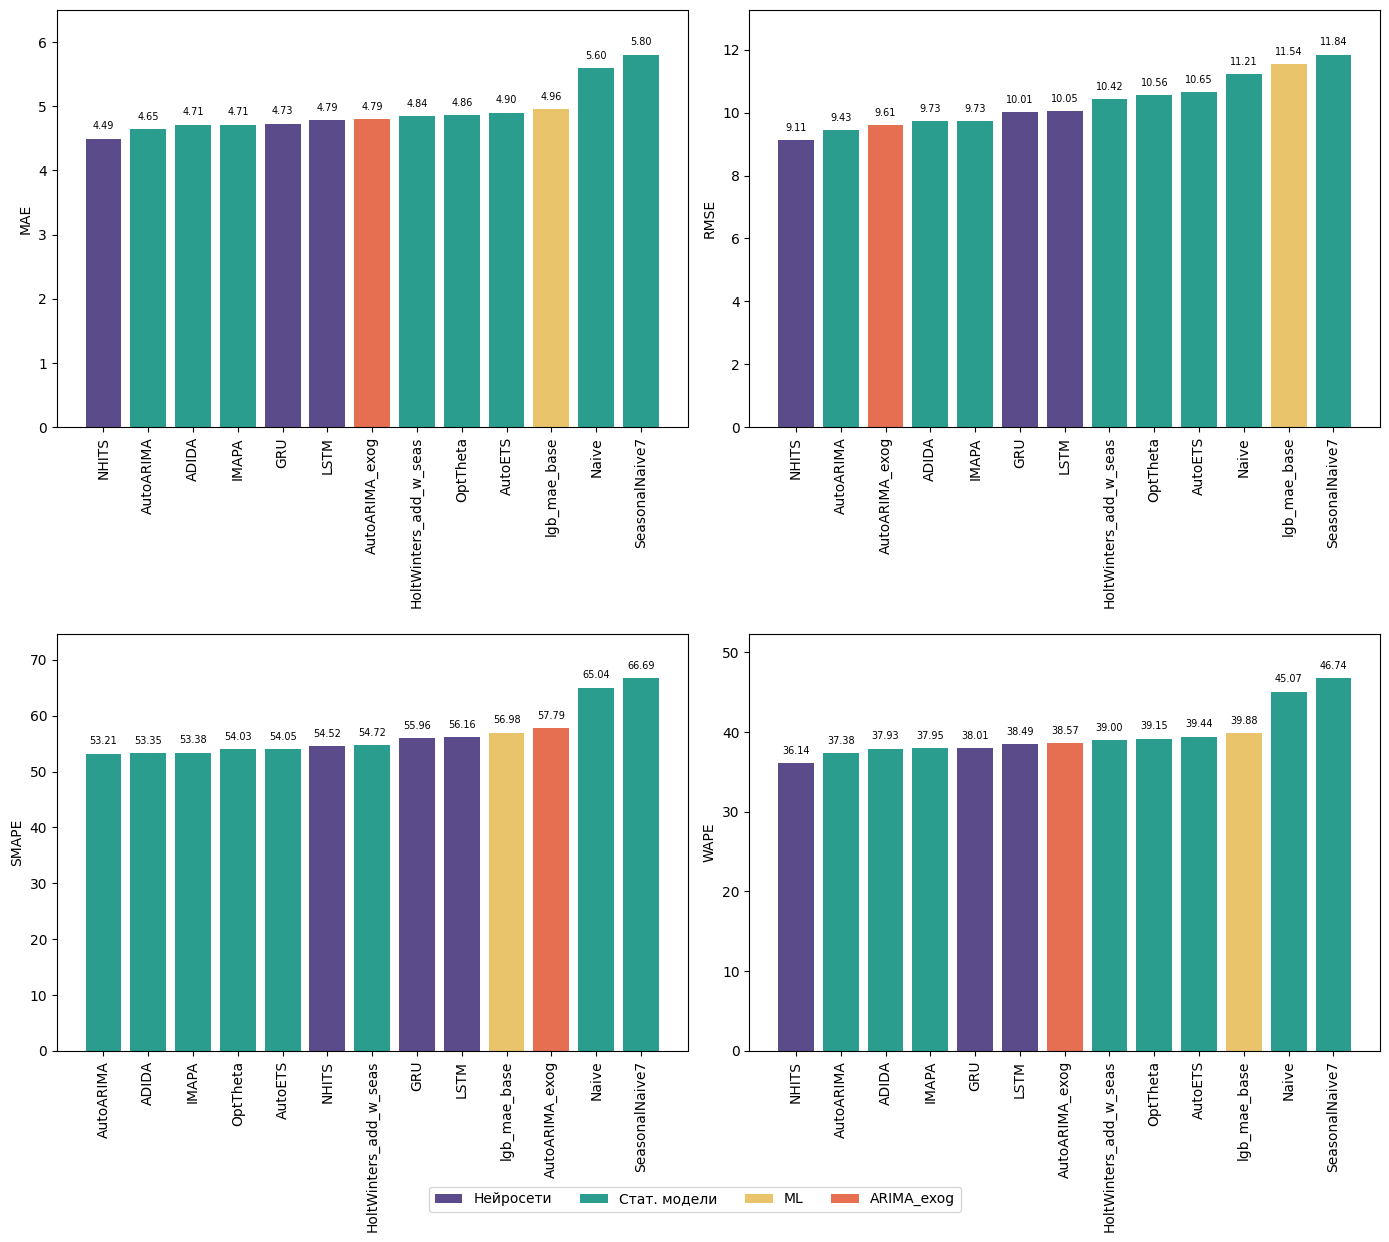

In [6]:
plot_metrics_bars(test_summary_mean_smooth, metrics=("mae", "rmse", "smape", "wape"), layout=(2, 2), figsize=(14, 12))

In [7]:
summary_money_smooth, money_cv_smooth = summarize_money_metrics(
    cv_results=cv_results_smooth,
    price_table=price_table,
    id_col="unique_id",
    y_col="y",
    price_col="price",
    extra_id_cols=("ds", "cutoff"),
)

summary_money_smooth

,mae_money,wape_money
model,,
NHITS,6742.588182,35.852518
AutoARIMA,6927.399488,36.835219
GRU,7028.644785,37.373573
ADIDA,7080.303792,37.648261
IMAPA,7082.392216,37.659365
LSTM,7100.139091,37.753731
AutoARIMA_exog,7143.025272,37.981771
HoltWinters_add_w_seas,7241.337971,38.504531
OptTheta,7251.745633,38.559872


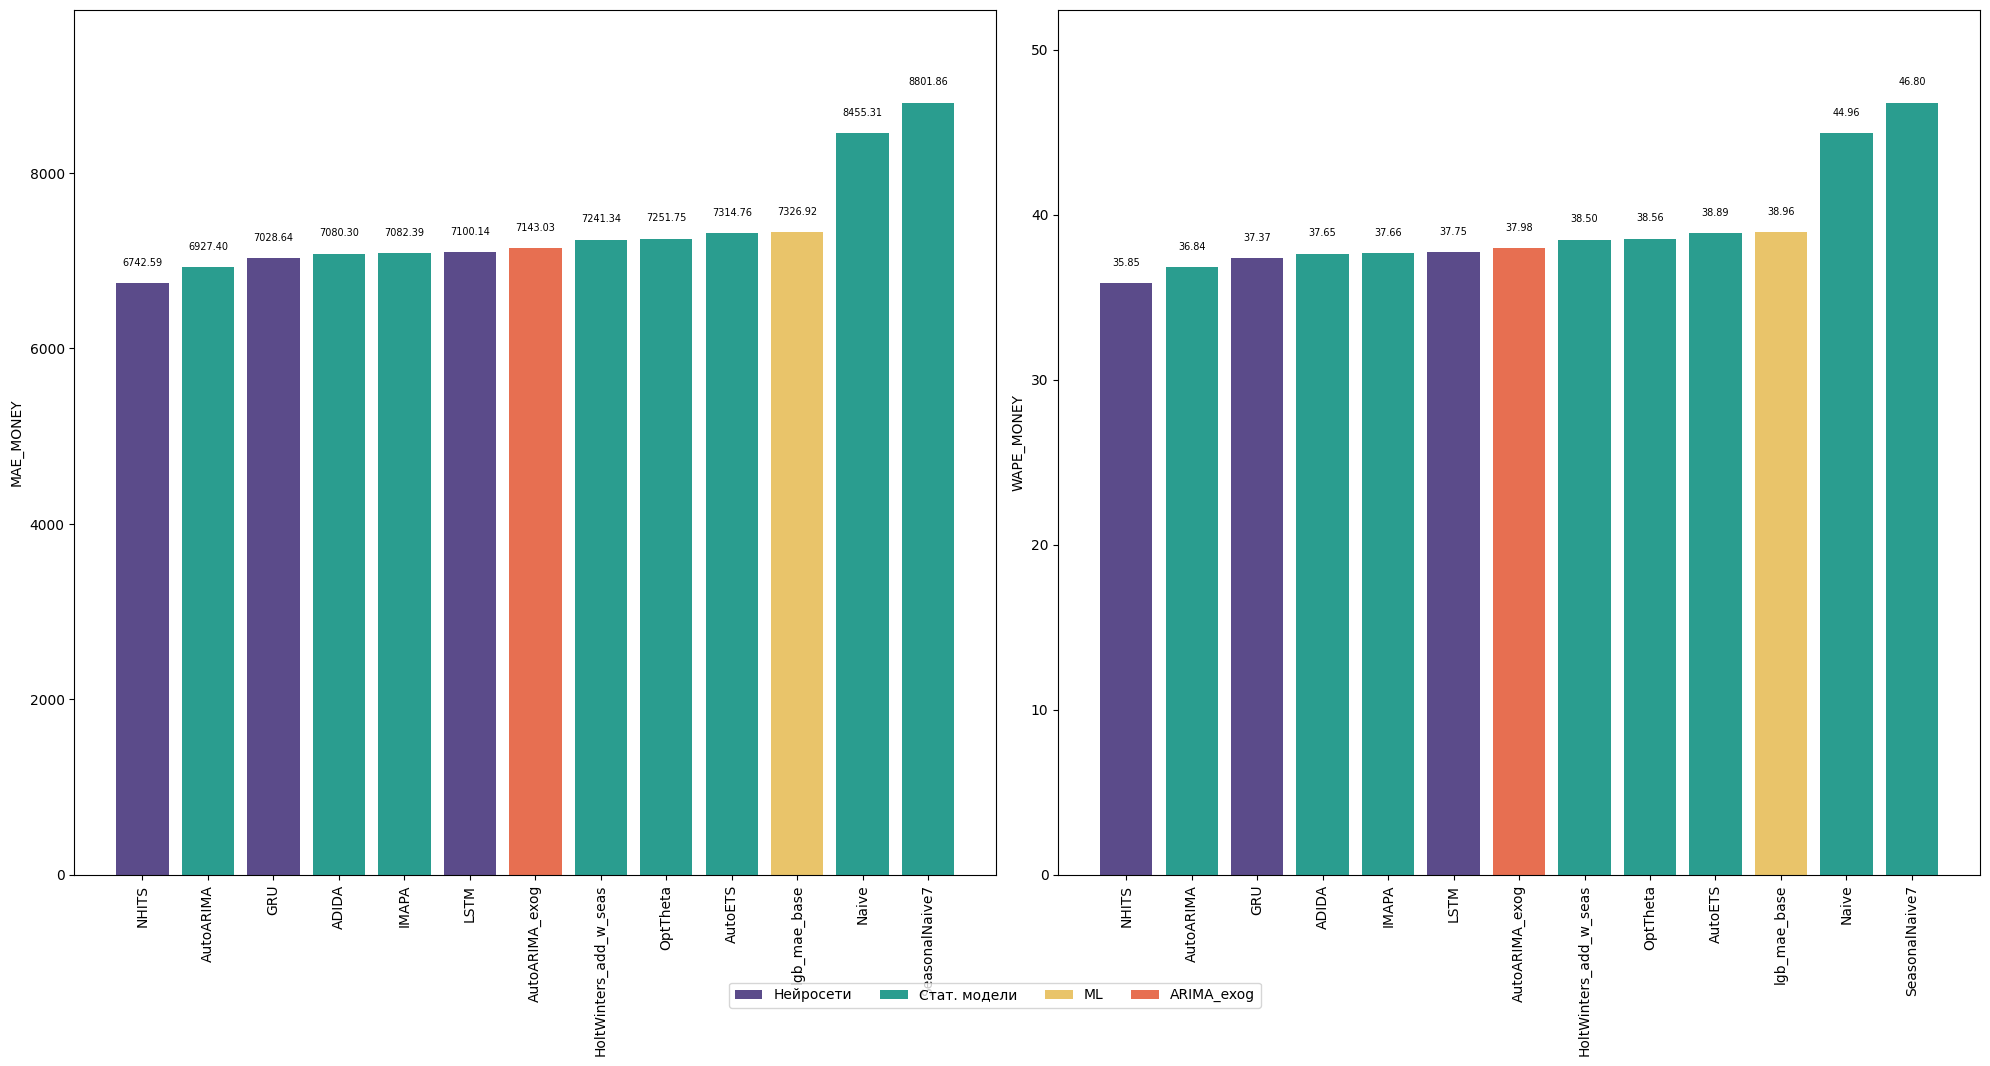

In [8]:
plot_metrics_bars(summary_money_smooth, metrics = ['mae_money', 'wape_money'], layout=(1, 2), figsize=(20, 10))

In [12]:
# подсчёт метрики смещения модели

grouped_sku = cv_results_smooth.groupby(['cutoff', 'unique_id'])[smooth_models].sum()
grouped_sku = grouped_sku[grouped_sku['y'] > 0]
sku_ratio = grouped_sku[smooth_models].div(grouped_sku['y'], axis=0)

window_stats = sku_ratio.groupby('cutoff').agg([
    'mean', 'median', 
    ('q25', lambda x: x.quantile(0.25)), 
    ('q75', lambda x: x.quantile(0.75))
])
smooth_bias_stats = window_stats.mean().unstack()
smooth_bias_stats.round(3)

grouped_cutoff = cv_results_smooth.groupby('cutoff')[smooth_models].sum()
grouped_cutoff = grouped_cutoff[grouped_cutoff['y'] > 0]
cutoff_ratio = grouped_cutoff[smooth_models].div(grouped_cutoff['y'], axis=0)

cutoff_ratio.mean().round(3)

y                         1.000
AutoARIMA_exog            0.952
lgb_mae_base              0.884
LSTM                      0.941
GRU                       0.927
NHITS                     0.907
SeasonalNaive7            1.023
Naive                     1.050
AutoETS                   1.045
AutoARIMA                 1.015
OptTheta                  1.045
HoltWinters_add_w_seas    1.031
ADIDA                     1.018
IMAPA                     1.019
dtype: float64

# Erratic

In [9]:
test_model_cols_erratic = get_model_columns(
    cv_results_erratic,
    reserved_columns=("unique_id", "ds", "cutoff", "y", "index", "test_window"),
)
test_metrics_per_window_erratic = compute_metrics_per_window(
    cv_results_erratic, test_model_cols_erratic, DEFAULT_METRICS
)
test_summary_mean_erratic, test_summary_stats_erratic = summarize_metrics(
    test_metrics_per_window_erratic
)

print("TEST mean metrics (3 windows x 14 days) - erratic:")
display(test_summary_mean_erratic)

TEST mean metrics (3 windows x 14 days) - erratic:


,mae,rmse,smape,wape
model,,,,
ADIDA,6.283328,27.067650,78.682838,71.526426
AutoARIMA,6.372729,27.607718,78.516470,72.640902
AutoARIMA_exog,6.398410,27.510723,84.271332,72.852763
AutoETS,6.675418,28.349351,80.832225,76.032219
GRU,5.989013,26.629105,82.828313,68.142435
IMAPA,6.286523,27.078871,78.806794,71.564469
LSTM,5.961453,26.612934,84.109039,67.819399
NHITS,5.662064,26.383175,78.879055,64.386672
Naive,6.903083,27.939519,91.831486,78.678502


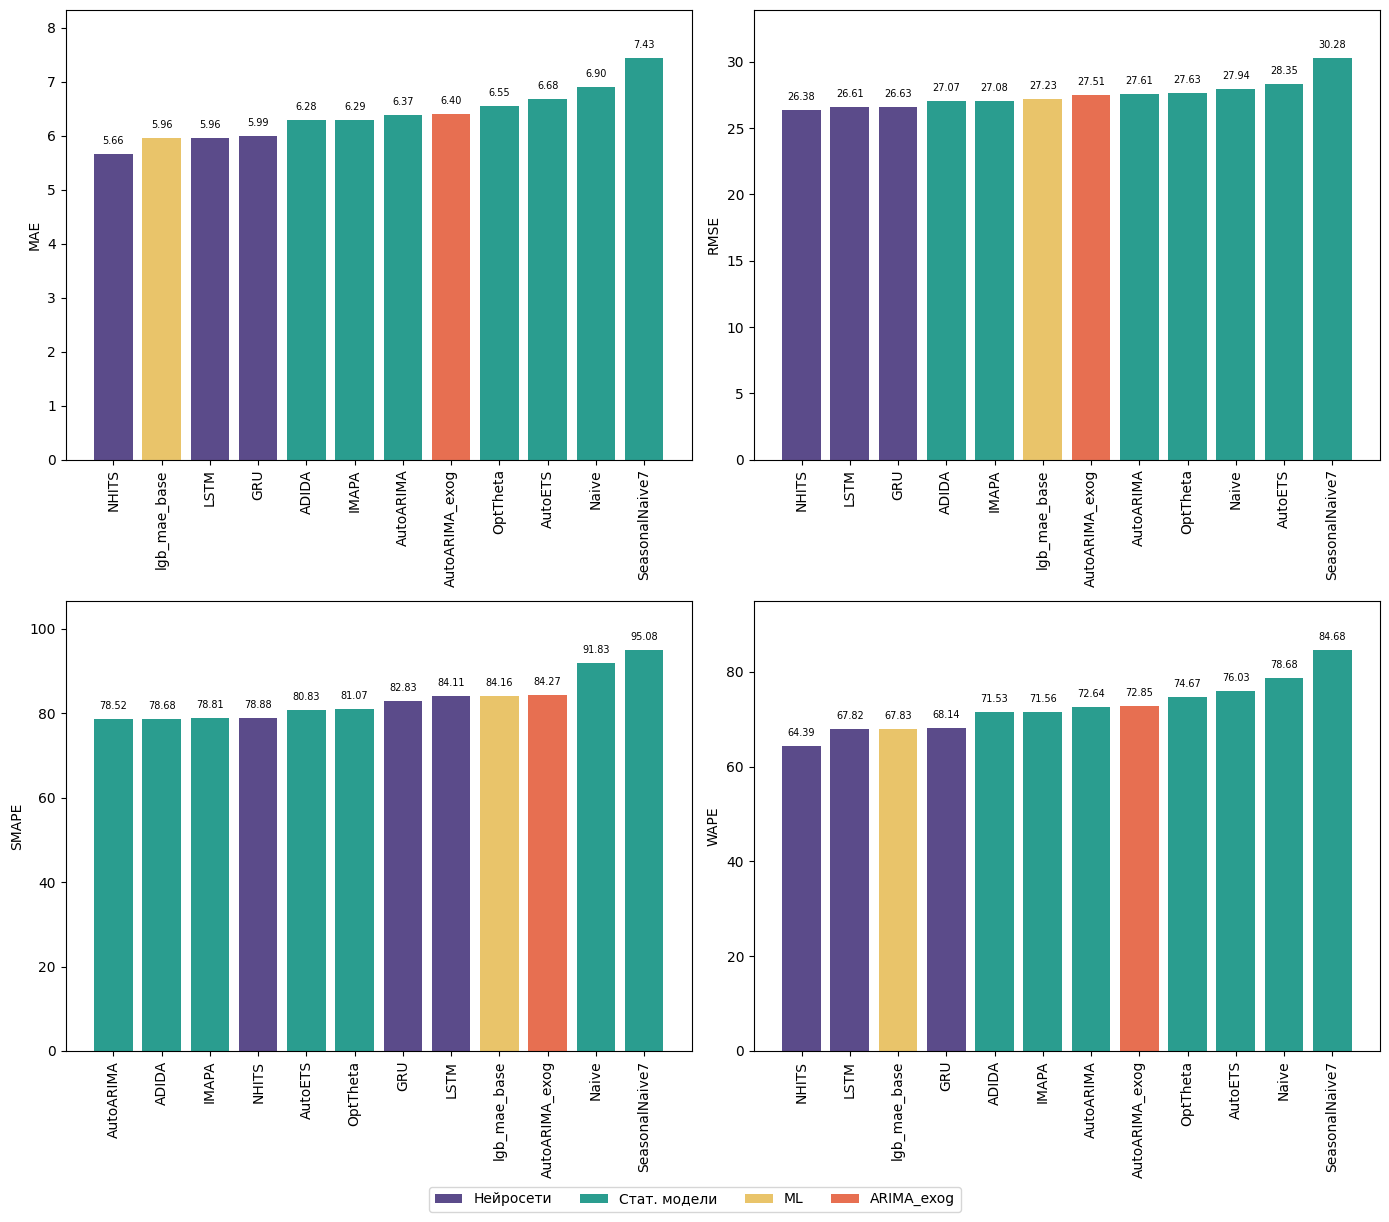

In [10]:
plot_metrics_bars(test_summary_mean_erratic, metrics=("mae", "rmse", "smape", "wape"), layout=(2, 2), figsize=(14, 12))

In [11]:
summary_money_erratic, money_cv_erratic = summarize_money_metrics(
    cv_results=cv_results_erratic,
    price_table=price_table,
    id_col="unique_id",
    y_col="y",
    price_col="price",
    extra_id_cols=("ds", "cutoff"),
)

summary_money_erratic

,mae_money,wape_money
model,,
NHITS,6893.590444,63.852276
lgb_mae_base,7254.316817,67.193525
LSTM,7255.496563,67.204452
GRU,7279.271225,67.424666
ADIDA,7673.074946,71.072296
IMAPA,7675.844103,71.097945
AutoARIMA,7798.283756,72.232050
AutoARIMA_exog,7923.911360,73.395682
OptTheta,8037.109423,74.444186


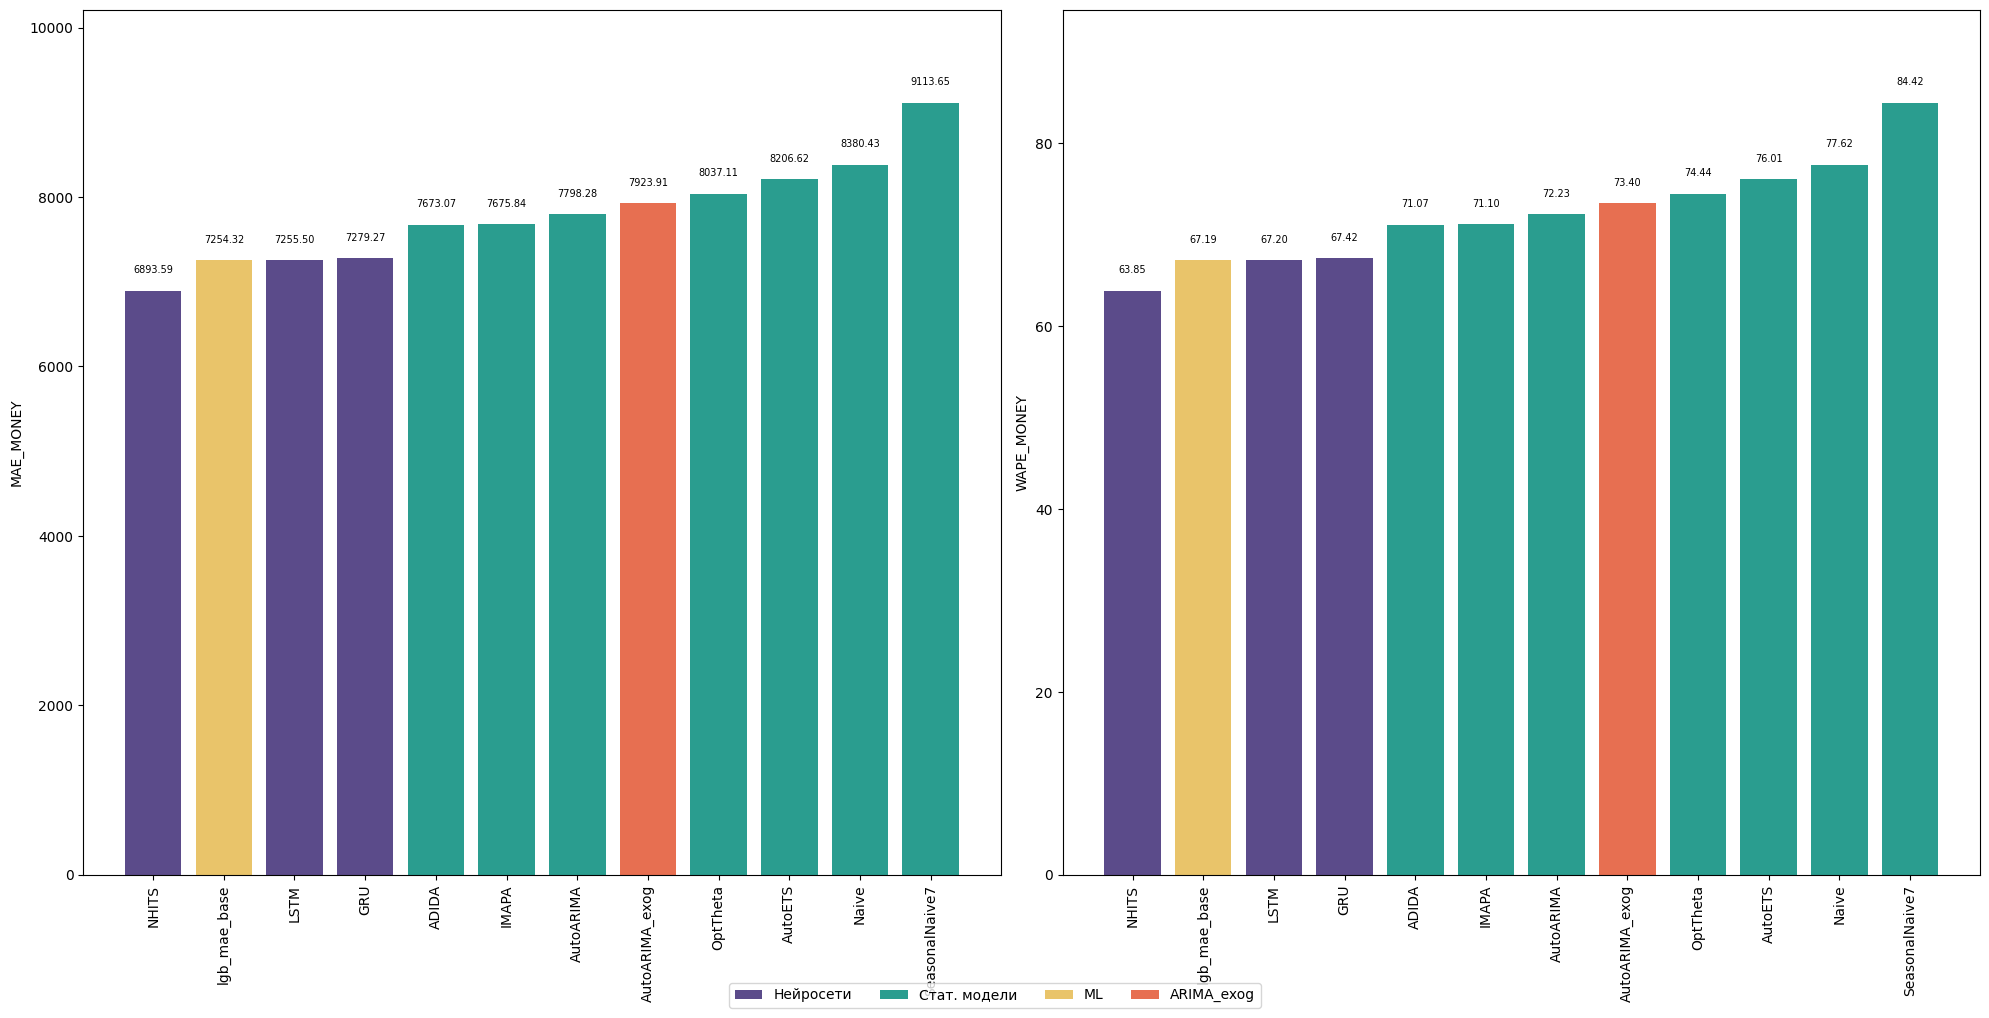

In [12]:
plot_metrics_bars(summary_money_erratic, metrics = ['mae_money', 'wape_money'], layout=(1, 2), figsize=(20, 10))

In [13]:
# подсчёт метрики смещения модели

grouped_sku = cv_results_erratic.groupby(['cutoff', 'unique_id'])[erratic_models].sum()
grouped_sku = grouped_sku[grouped_sku['y'] > 0]
sku_ratio = grouped_sku[erratic_models].div(grouped_sku['y'], axis=0)

# статистики внутри окна: среднее, медиана, 25-й и 75-й перцентили
window_stats = sku_ratio.groupby('cutoff').agg([
    'mean', 'median', 
    ('q25', lambda x: x.quantile(0.25)), 
    ('q75', lambda x: x.quantile(0.75))
])

erratic_bias_stats = window_stats.mean().unstack()

grouped_cutoff = cv_results_erratic.groupby('cutoff')[erratic_models].sum()
grouped_cutoff = grouped_cutoff[grouped_cutoff['y'] > 0]
cutoff_ratio = grouped_cutoff[erratic_models].div(grouped_cutoff['y'], axis=0)

cutoff_ratio.mean().round(3)

y                 1.000
AutoARIMA_exog    0.914
lgb_mae_base      0.733
LSTM              0.796
GRU               0.826
NHITS             0.822
SeasonalNaive7    0.967
Naive             0.979
AutoETS           1.026
AutoARIMA         1.018
OptTheta          1.014
ADIDA             0.985
IMAPA             0.985
dtype: float64

# Intermittent

In [13]:
test_model_cols_intermittent = get_model_columns(
    cv_results_intermittent,
    reserved_columns=("unique_id", "ds", "cutoff", "y", "index", "test_window"),
)
test_metrics_per_window_intermittent = compute_metrics_per_window(
    cv_results_intermittent, test_model_cols_intermittent, DEFAULT_METRICS
)
test_summary_mean_intermittent, test_summary_stats_intermittent = summarize_metrics(
    test_metrics_per_window_intermittent
)

print("TEST mean metrics (3 windows x 14 days) - intermittent:")
display(test_summary_mean_intermittent)

TEST mean metrics (3 windows x 14 days) - intermittent:


,mae,rmse,smape,wape
model,,,,
ADIDA,0.457752,0.870903,177.961101,118.725107
AutoARIMA_exog,0.446281,0.930174,176.336805,115.799323
AutoETS,0.468405,0.901060,177.986524,121.485571
CrostonOpt,0.514976,0.904196,176.883612,133.561270
CrostonSBA,0.514637,0.901643,177.374279,133.470942
GRU,0.353528,0.922824,180.127833,91.673480
IMAPA,0.455681,0.871657,177.860431,118.190414
LSTM,0.353312,0.921101,180.111264,91.620101
NHITS,0.369701,0.956542,191.660996,95.872954


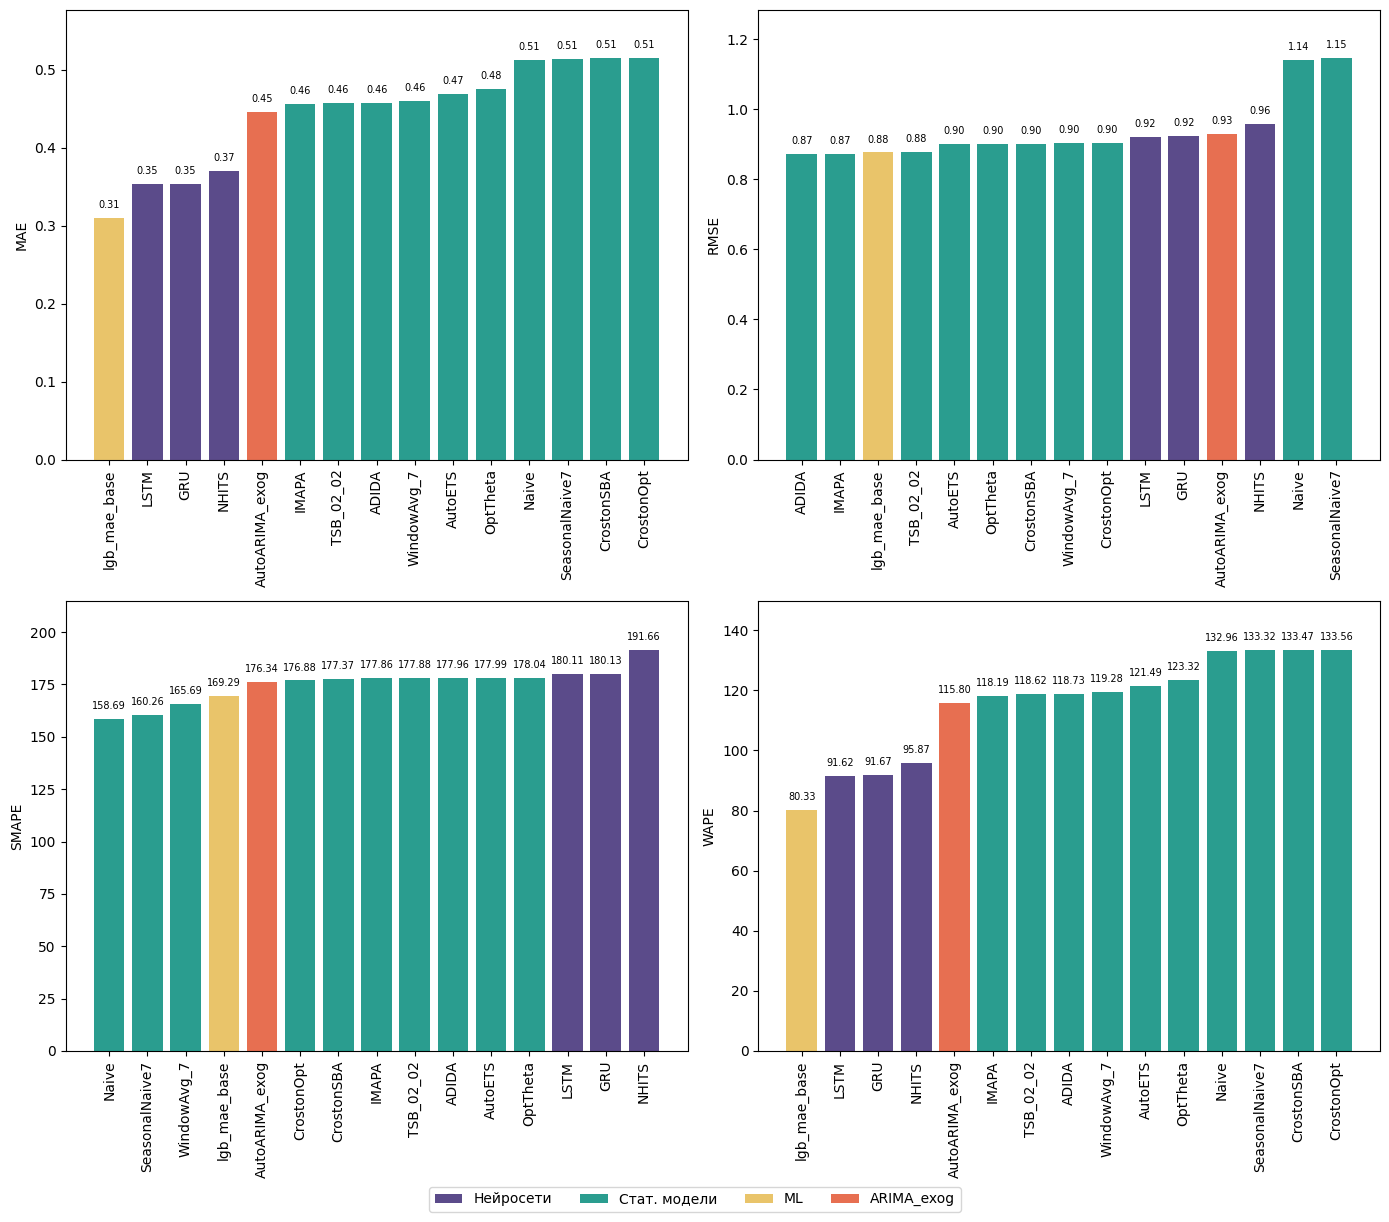

In [14]:
plot_metrics_bars(test_summary_mean_intermittent, metrics=("mae", "rmse", "smape", "wape"), layout=(2, 2), figsize=(14, 12))

In [15]:
summary_money_intermittent, money_cv_intermittent = summarize_money_metrics(
    cv_results=cv_results_intermittent,
    price_table=price_table,
    id_col="unique_id",
    y_col="y",
    price_col="price",
    extra_id_cols=("ds", "cutoff"),
)

summary_money_intermittent

,mae_money,wape_money
model,,
lgb_mae_base,634.376583,81.536491
GRU,730.298122,93.865297
LSTM,730.358385,93.873043
NHITS,753.368483,96.830533
AutoARIMA_exog,909.749720,116.930231
IMAPA,945.042575,121.466425
ADIDA,947.599752,121.795100
TSB_02_02,952.212175,122.387935
WindowAvg_7,960.250663,123.421123


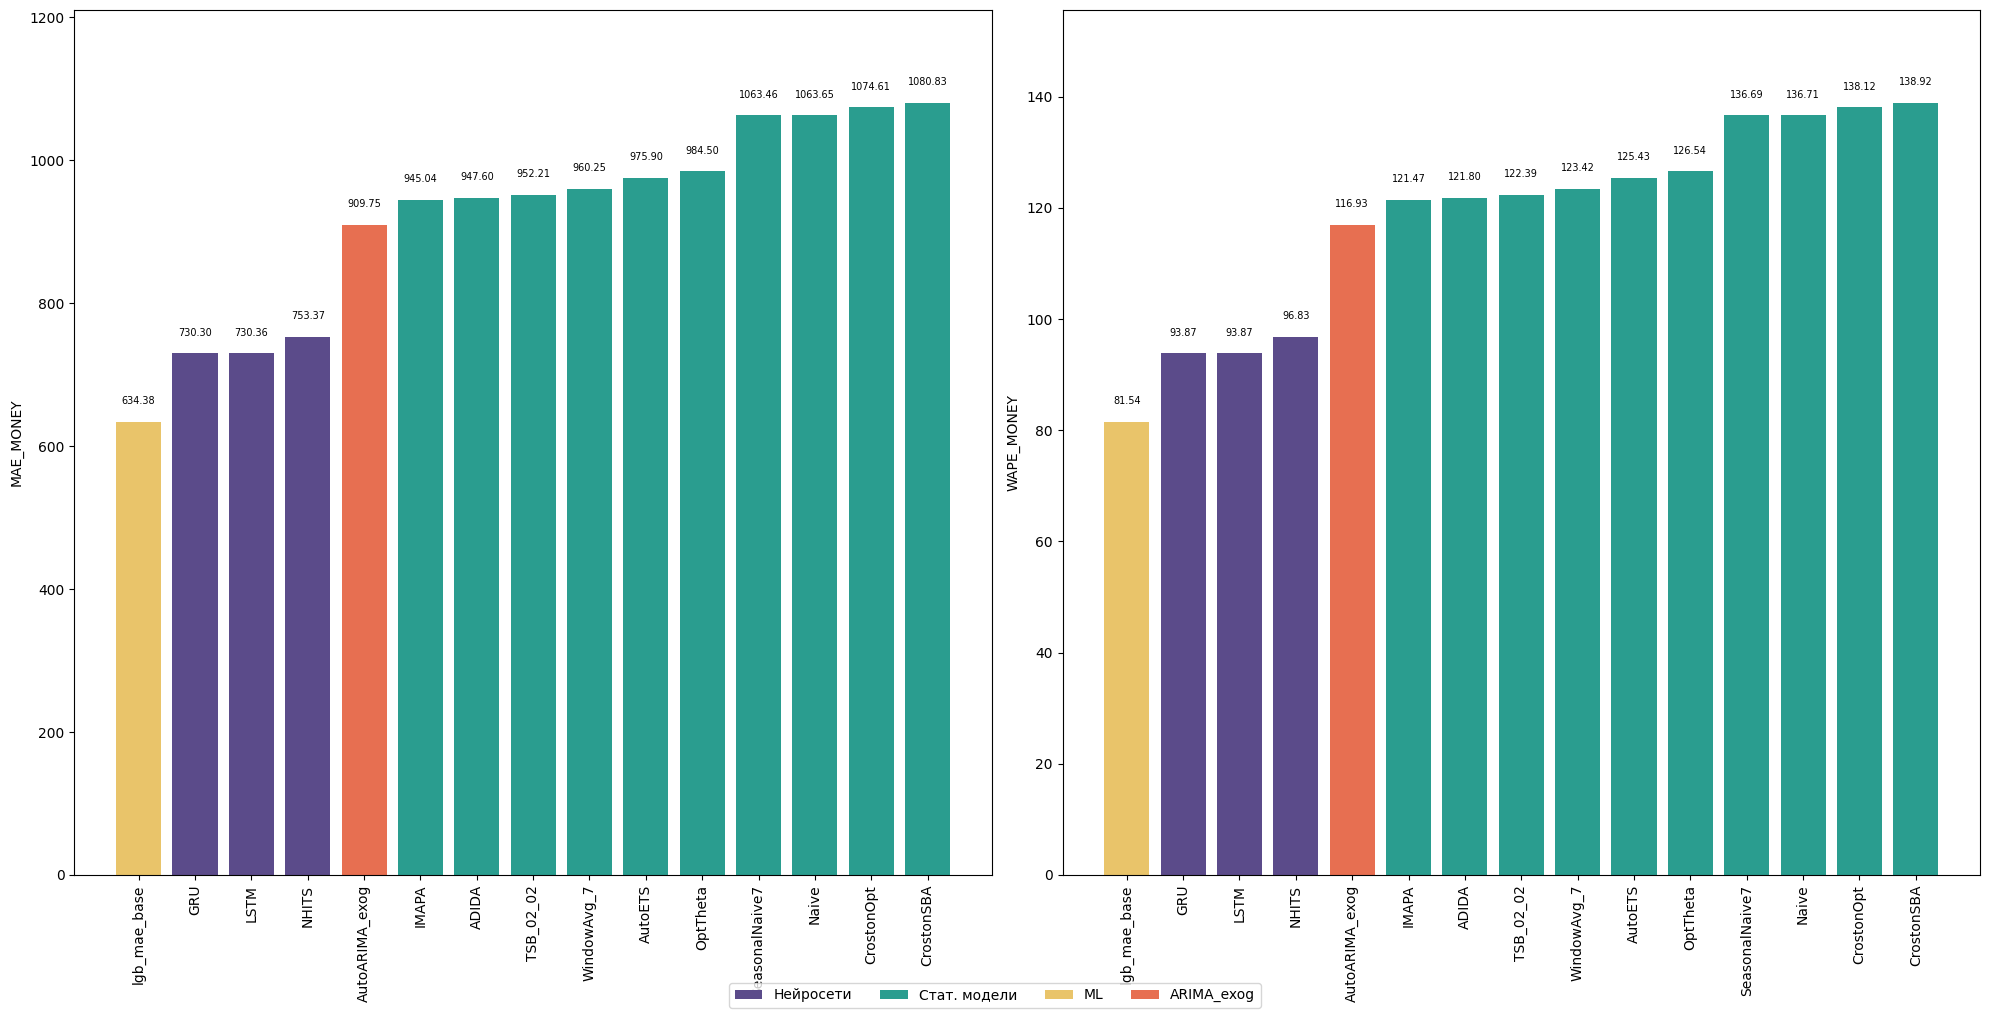

In [16]:
plot_metrics_bars(summary_money_intermittent, metrics = ['mae_money', 'wape_money'], layout=(1, 2), figsize=(20, 10))

In [15]:
# подсчёт метрики смещения модели

grouped_sku = cv_results_intermittent.groupby(['cutoff', 'unique_id'])[intermittent_models].sum()
grouped_sku = grouped_sku[grouped_sku['y'] > 0]
sku_ratio = grouped_sku[intermittent_models].div(grouped_sku['y'], axis=0)

window_stats = sku_ratio.groupby('cutoff').agg([
    'mean', 'median', 
    ('q25', lambda x: x.quantile(0.25)), 
    ('q75', lambda x: x.quantile(0.75))
])
intermittent_bias_stats = window_stats.mean().unstack()

grouped_cutoff = cv_results_intermittent.groupby('cutoff')[intermittent_models].sum()
grouped_cutoff = grouped_cutoff[grouped_cutoff['y'] > 0]
cutoff_ratio = grouped_cutoff[intermittent_models].div(grouped_cutoff['y'], axis=0)

cutoff_ratio.mean().round(3)

y                 1.000
AutoARIMA_exog    0.997
lgb_mae_base      0.471
LSTM              0.673
GRU               0.672
NHITS             0.271
Naive             1.059
SeasonalNaive7    1.031
WindowAvg_7       1.031
OptTheta          1.017
AutoETS           1.044
CrostonOpt        1.176
CrostonSBA        1.123
TSB_02_02         1.032
ADIDA             1.002
IMAPA             1.009
dtype: float64

# Lumpy

In [17]:
test_model_cols_lumpy = get_model_columns(
    cv_results_lumpy,
    reserved_columns=("unique_id", "ds", "cutoff", "y", "index", "test_window"),
)
test_metrics_per_window_lumpy = compute_metrics_per_window(
    cv_results_lumpy, test_model_cols_lumpy, DEFAULT_METRICS
)
test_summary_mean_lumpy, test_summary_stats_lumpy = summarize_metrics(
    test_metrics_per_window_lumpy
)

print("TEST mean metrics (3 windows x 14 days) - lumpy:")
display(test_summary_mean_lumpy)

TEST mean metrics (3 windows x 14 days) - lumpy:


,mae,rmse,smape,wape
model,,,,
ADIDA,1.210814,2.629790,154.013493,109.593991
AutoARIMA_exog,1.236571,2.963294,156.507089,111.858468
AutoETS,1.265911,2.806365,155.630384,114.581422
CrostonOpt,1.297146,2.742330,152.072156,117.389693
CrostonSBA,1.280876,2.702826,152.238819,115.920794
GRU,1.017662,2.719345,161.741739,92.097273
IMAPA,1.210738,2.628658,154.193029,109.584590
LSTM,1.018545,2.723377,161.938117,92.176838
NHITS,1.022916,2.689700,174.509907,92.586341


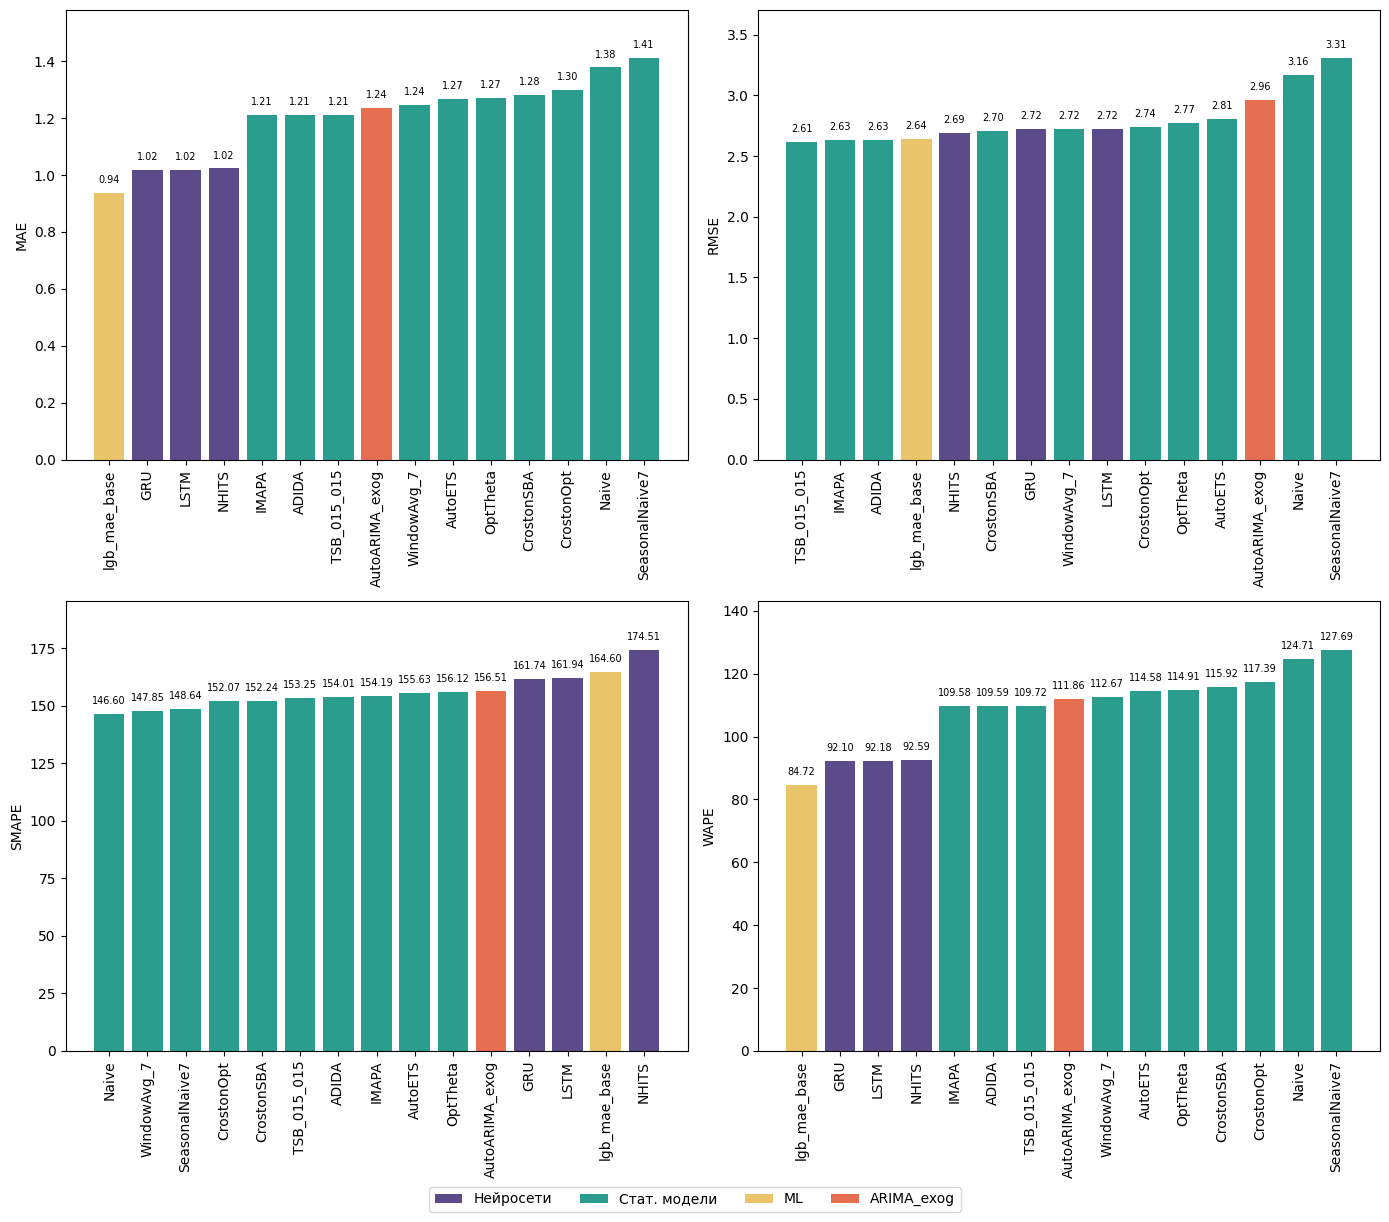

In [18]:
plot_metrics_bars(test_summary_mean_lumpy, metrics=("mae", "rmse", "smape", "wape"), layout=(2, 2), figsize=(14, 12))

In [19]:
summary_money_lumpy, money_cv_lumpy = summarize_money_metrics(
    cv_results=cv_results_lumpy,
    price_table=price_table,
    id_col="unique_id",
    y_col="y",
    price_col="price",
    extra_id_cols=("ds", "cutoff"),
)

summary_money_lumpy

,mae_money,wape_money
model,,
lgb_mae_base,1428.378205,85.729816
GRU,1539.032208,92.371158
NHITS,1540.025175,92.430754
LSTM,1540.509058,92.459797
ADIDA,1819.327975,109.194226
TSB_015_015,1821.006953,109.294997
IMAPA,1823.535464,109.446755
WindowAvg_7,1872.539028,112.387900
AutoARIMA_exog,1885.417277,113.160839


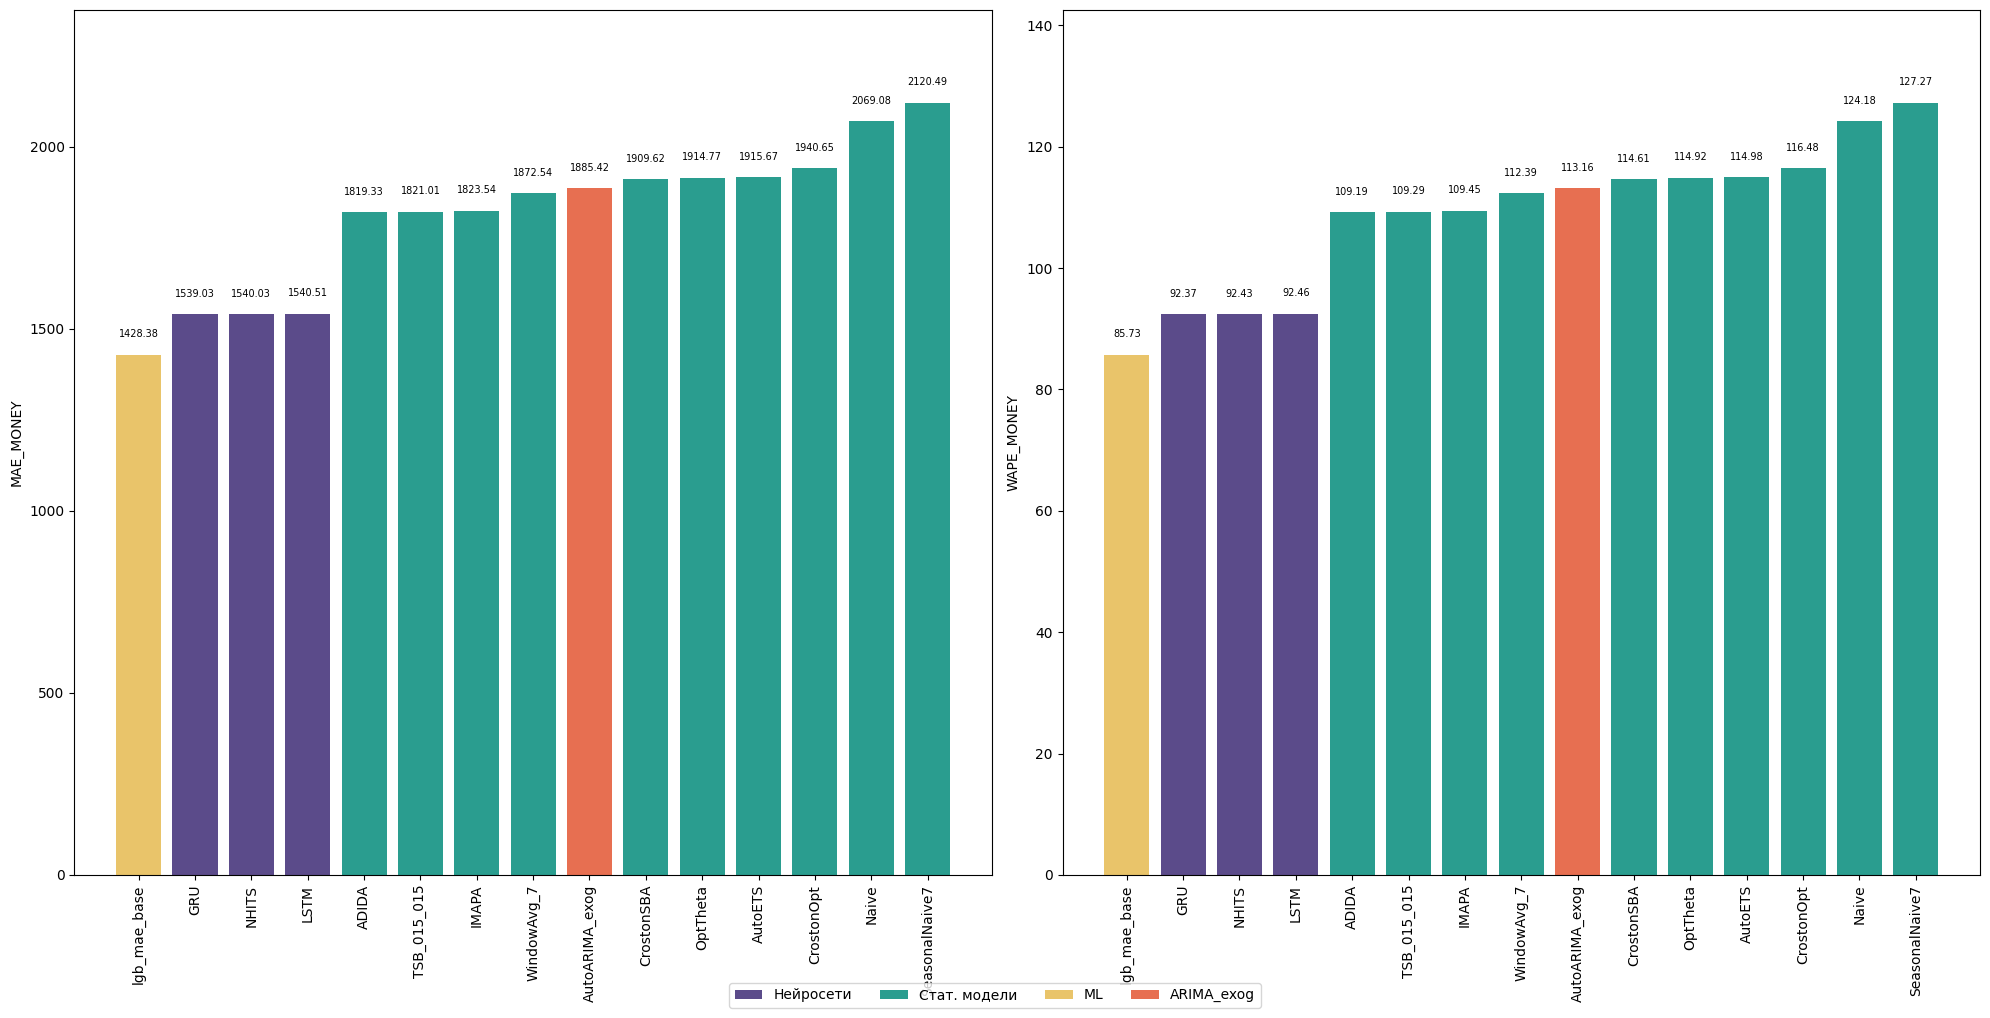

In [20]:
plot_metrics_bars(summary_money_lumpy, metrics = ['mae_money', 'wape_money'], layout=(1, 2), figsize=(20, 10))

In [16]:
# подсчёт метрики смещения модели
grouped_sku = cv_results_lumpy.groupby(['cutoff', 'unique_id'])[lumpy_models].sum()
grouped_sku = grouped_sku[grouped_sku['y'] > 0]
sku_ratio = grouped_sku[lumpy_models].div(grouped_sku['y'], axis=0)

window_stats = sku_ratio.groupby('cutoff').agg([
    'mean', 'median', 
    ('q25', lambda x: x.quantile(0.25)), 
    ('q75', lambda x: x.quantile(0.75))
])
lumpy_bias_stats = window_stats.mean().unstack()

grouped_cutoff = cv_results_lumpy.groupby('cutoff')[lumpy_models].sum()
grouped_cutoff = grouped_cutoff[grouped_cutoff['y'] > 0]
cutoff_ratio = grouped_cutoff[lumpy_models].div(grouped_cutoff['y'], axis=0)

cutoff_ratio.mean().round(3)

y                 1.000
AutoARIMA_exog    0.902
lgb_mae_base      0.455
LSTM              0.607
GRU               0.612
NHITS             0.362
Naive             1.021
SeasonalNaive7    0.989
WindowAvg_7       0.989
OptTheta          1.011
AutoETS           1.033
TSB_015_015       0.985
CrostonOpt        1.060
CrostonSBA        0.991
ADIDA             0.958
IMAPA             0.973
dtype: float64